In [5]:
!pip install leia-br -q

In [6]:
import re
import nltk
import spacy
import string
import textstat
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from unidecode import unidecode as _unidecode
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

nltk.download('cmudict')
textstat.set_lang("pt")

[nltk_data] Downloading package cmudict to
[nltk_data]     C:\Users\redga\AppData\Roaming\nltk_data...
[nltk_data]   Package cmudict is already up-to-date!


## Criando, Filtrando e Limpando a Base

In [7]:
nlp = spacy.load("pt_core_news_lg", disable=["ner", "parser"])

def normalize_unidecode(text: str) -> str:
    return _unidecode(text)

def base_clean_pt(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = re.sub(r'\s+', ' ', text.strip()) # remove breaks and normalize spaces
    text = re.sub(r'<[^>]+>', '', text) # remove HTML, URLs, and emails
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = normalize_unidecode(text) # normalize accents
    text = re.sub(r'\b[a-zA-Z]*\d+[a-zA-Z]*\b', ' ', text) # remove alphanumeric tokens of type Q12, A1, C3
    text = re.sub(r'[^\w\s\-\']', ' ', text) # remove loose punctuation (keep hyphens and apostrophes within words if they exist)
    text = re.sub(r'\s+', ' ', text).strip() # normalize spaces again
    return text.lower()

def spacy_process(texts, lemmatize = False, remove_stopwords = False, batch_size=512):
    cleaned = (base_clean_pt(t) for t in texts)
    results = []

    for doc in nlp.pipe(cleaned, batch_size=batch_size):
        tokens = []
        for tok in doc:
            if tok.is_punct or tok.is_space or tok.like_num or len(tok.text) <= 2:
                continue
            if remove_stopwords and tok.is_stop:
                continue

            token = tok.lemma_ if lemmatize else tok.text
            tokens.append(token.lower())

        results.append(" ".join(tokens))

    return results

def data_preprocessing(df, column_name):
    df["UNCLEAN_TEXT"] = (
        df[column_name]
        .fillna("")
        .astype(str)
    )

    df["CLEAN_TEXT"] = spacy_process(
        df["UNCLEAN_TEXT"],
        lemmatize=False,
        remove_stopwords=False
    )

    return df

In [8]:
df_1 = pd.read_csv("../data/goemotions_1_pt.csv")
df_2 = pd.read_csv("../data/goemotions_2_pt.csv")
df_3 = pd.read_csv("../data/goemotions_3_pt.csv")

df = pd.concat([df_1, df_2, df_3])
df.drop(columns=['author', 'subreddit', 'link_id', 'parent_id', 'created_utc'], inplace=True)

print(df.shape)

emotion_cols = [
    'admiration', 'amusement', 'anger', 'annoyance',
    'approval', 'caring', 'confusion', 'curiosity', 'desire',
    'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
    'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]

for c in emotion_cols:
    df[c] = (
        df.groupby('id')[c]
        .transform('sum')
        .ge(2)
        .astype(int)
    )

df['label_sum'] = df[emotion_cols].sum(axis=1)
df = df[df['label_sum'] > 0]

df = (
    df
    .groupby('id', as_index=False)
    .agg(
        {
            **{c: 'max' for c in emotion_cols},
            'text': 'first',
            'texto': 'first'
        }
    )
)

print(df.shape)  # ~54k

conflicts = (
    df
    .groupby('id')[emotion_cols]
    .nunique()
    .max(axis=1)
)

print((conflicts > 1).sum()) # 0

df = data_preprocessing(df, 'texto')

n_nan = df['CLEAN_TEXT'].isna().sum()

n_empty = (df['CLEAN_TEXT'].str.strip() == '').sum()

print(f'Textos NaN: {n_nan}')
print(f'Textos vazios ou em branco: {n_empty}')
print(f'Total problemáticos: {n_nan + n_empty}')

df = df.dropna(subset=['CLEAN_TEXT'])
df = df[df['CLEAN_TEXT'].str.strip() != '']

print(df.shape)
print(df.columns)
df.head(1)

(211225, 33)
(54263, 31)
0
Textos NaN: 0
Textos vazios ou em branco: 29
Total problemáticos: 29
(54234, 33)
Index(['id', 'admiration', 'amusement', 'anger', 'annoyance', 'approval',
       'caring', 'confusion', 'curiosity', 'desire', 'disappointment',
       'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear',
       'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride',
       'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral',
       'text', 'texto', 'UNCLEAN_TEXT', 'CLEAN_TEXT'],
      dtype='str')


,id,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,...,realization,relief,remorse,sadness,surprise,neutral,text,texto,UNCLEAN_TEXT,CLEAN_TEXT
0,eczazk6,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,Fast as [NAME] will carry me. Seriously uptown...,Tão rápido quanto [NOME] me carregará. Seriame...,Tão rápido quanto [NOME] me carregará. Seriame...,tao rapido quanto nome carregara seriamente up...


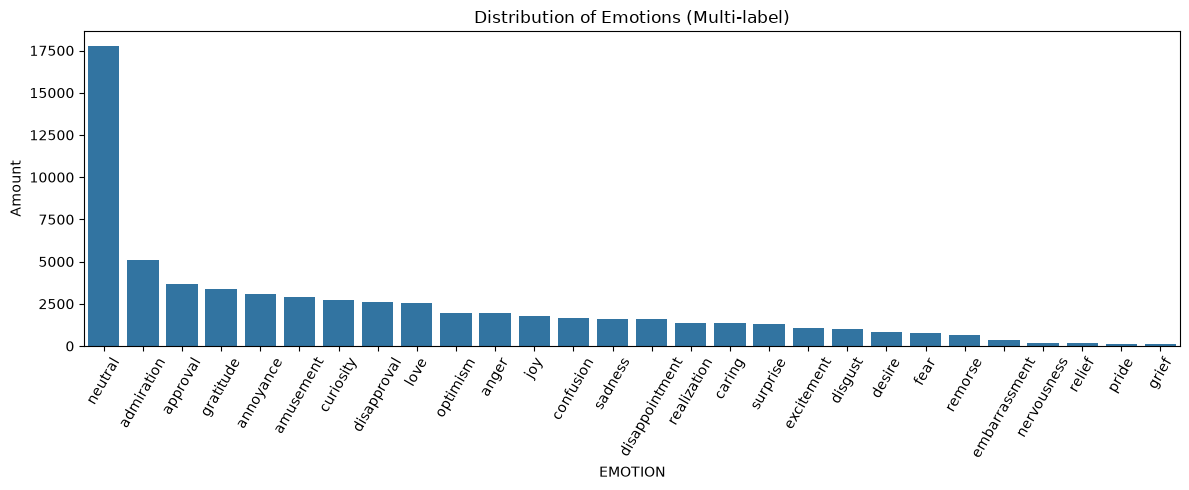

In [9]:
emotion_counts = df[emotion_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(
    x=emotion_counts.index,
    y=emotion_counts.values
)

plt.xticks(rotation=60)
plt.ylabel("Amount")
plt.xlabel("EMOTION")
plt.title("Distribution of Emotions (Multi-label)")
plt.tight_layout()
plt.show()

## Engenharia de Features

In [10]:
nlp = spacy.load("pt_core_news_lg", disable=["ner"])

AUXILIARY_VERBS_PT = {
    "ser", "estar", "ter", "haver", "ir"
}

def get_textstat_features(texts):
    features = []
    for x in texts:
        n_sent = max(textstat.sentence_count(x), 1)
        n_words = max(textstat.lexicon_count(x), 1)

        features.append([
            textstat.letter_count(x),
            n_sent,
            textstat.avg_letter_per_word(x),
            n_words / n_sent,
            textstat.avg_syllables_per_word(x),
            textstat.reading_time(x),
        ])
    return np.array(features)

def mean_punctuation_per_word(texts):
    punct = set(string.punctuation)
    results = []

    for txt in texts:
        words = txt.split()
        n_words = len(words)

        if n_words == 0:
            results.append([0.0, 0.0, 0.0])
            continue

        total_punct = sum(1 for ch in txt if ch in punct)
        exclam = txt.count("!")
        quest = txt.count("?")
        
        results.append([
            total_punct / n_words,
            exclam / n_words,
            quest / n_words
        ])
    return np.array(results)

def mean_verbs_per_word(texts):
    feats = []
    for doc in nlp.pipe(texts, batch_size=256, disable=["ner", "lemmatizer", "parser"]):
        words = [t for t in doc if t.is_alpha]
        if len(words) == 0:
            feats.append(0.0)
            continue
        verb_count = sum(1 for t in words if t.pos_ == "VERB")
        feats.append(verb_count / len(words))
    return np.array(feats).reshape(-1, 1)

def mean_auxiliaries_per_word(texts):
    results = []
    for doc in nlp.pipe(texts, batch_size=256, disable=["ner", "parser"]):
        tokens = [tok for tok in doc if tok.is_alpha]
        if len(tokens) == 0:
            results.append(0.0)
            continue

        aux_count = sum(1 for tok in tokens if tok.lemma_.lower() in AUXILIARY_VERBS_PT)
        results.append(aux_count / len(tokens))
    return results

def mean_auxiliaries_per_sentence(texts):
    results = []
    for doc in nlp.pipe(texts, batch_size=256, disable=["ner"]):
        n_sent = len(list(doc.sents))
        if n_sent == 0:
            results.append(0.0)
            continue

        tokens = [tok for tok in doc if tok.is_alpha]

        aux_count = sum(
            1 for tok in tokens
            if tok.lemma_.lower() in AUXILIARY_VERBS_PT
        )

        results.append(aux_count / n_sent)
    return np.array(results)

def flesch_portuguese(texts):
    scores = []
    for t in texts:
        text = str(t).strip()

        num_sent = textstat.sentence_count(text)
        num_words = len(text.split())
        num_syll = textstat.syllable_count(text)

        if num_sent == 0 or num_words == 0:
            scores.append(0.0)
            continue

        flesch_pt = 226 - 1.04 * (num_words / num_sent) - 72 * (num_syll / num_words)
        scores.append(flesch_pt)

    return scores

def uppercase_percentage(texts):
    results = []

    for txt in texts:
        letters = [ch for ch in txt if ch.isalpha()]
        if len(letters) == 0:
            results.append(0.0)
            continue

        upper = sum(1 for ch in letters if ch.isupper())
        results.append(upper / len(letters))

    return np.array(results).reshape(-1, 1)

def mean_unique_word_length(texts):
    results = []

    for txt in texts:
        words = [w.lower() for w in txt.split() if w.isalpha()]
        unique_words = set(words)

        if len(unique_words) == 0:
            results.append(0.0)
            continue

        mean_len = np.mean([len(w) for w in unique_words])
        results.append(mean_len)

    return np.array(results).reshape(-1, 1)

def mean_char_repetition_per_word(texts):
    results = []
    pattern = re.compile(r"(.)\1{2,}")  # 3+ repetições

    for txt in texts:
        words = txt.split()
        if len(words) == 0:
            results.append(0.0)
            continue

        repeated_words = sum(
            1 for w in words if pattern.search(w.lower())
        )

        results.append(repeated_words / len(words))

    return np.array(results).reshape(-1, 1)

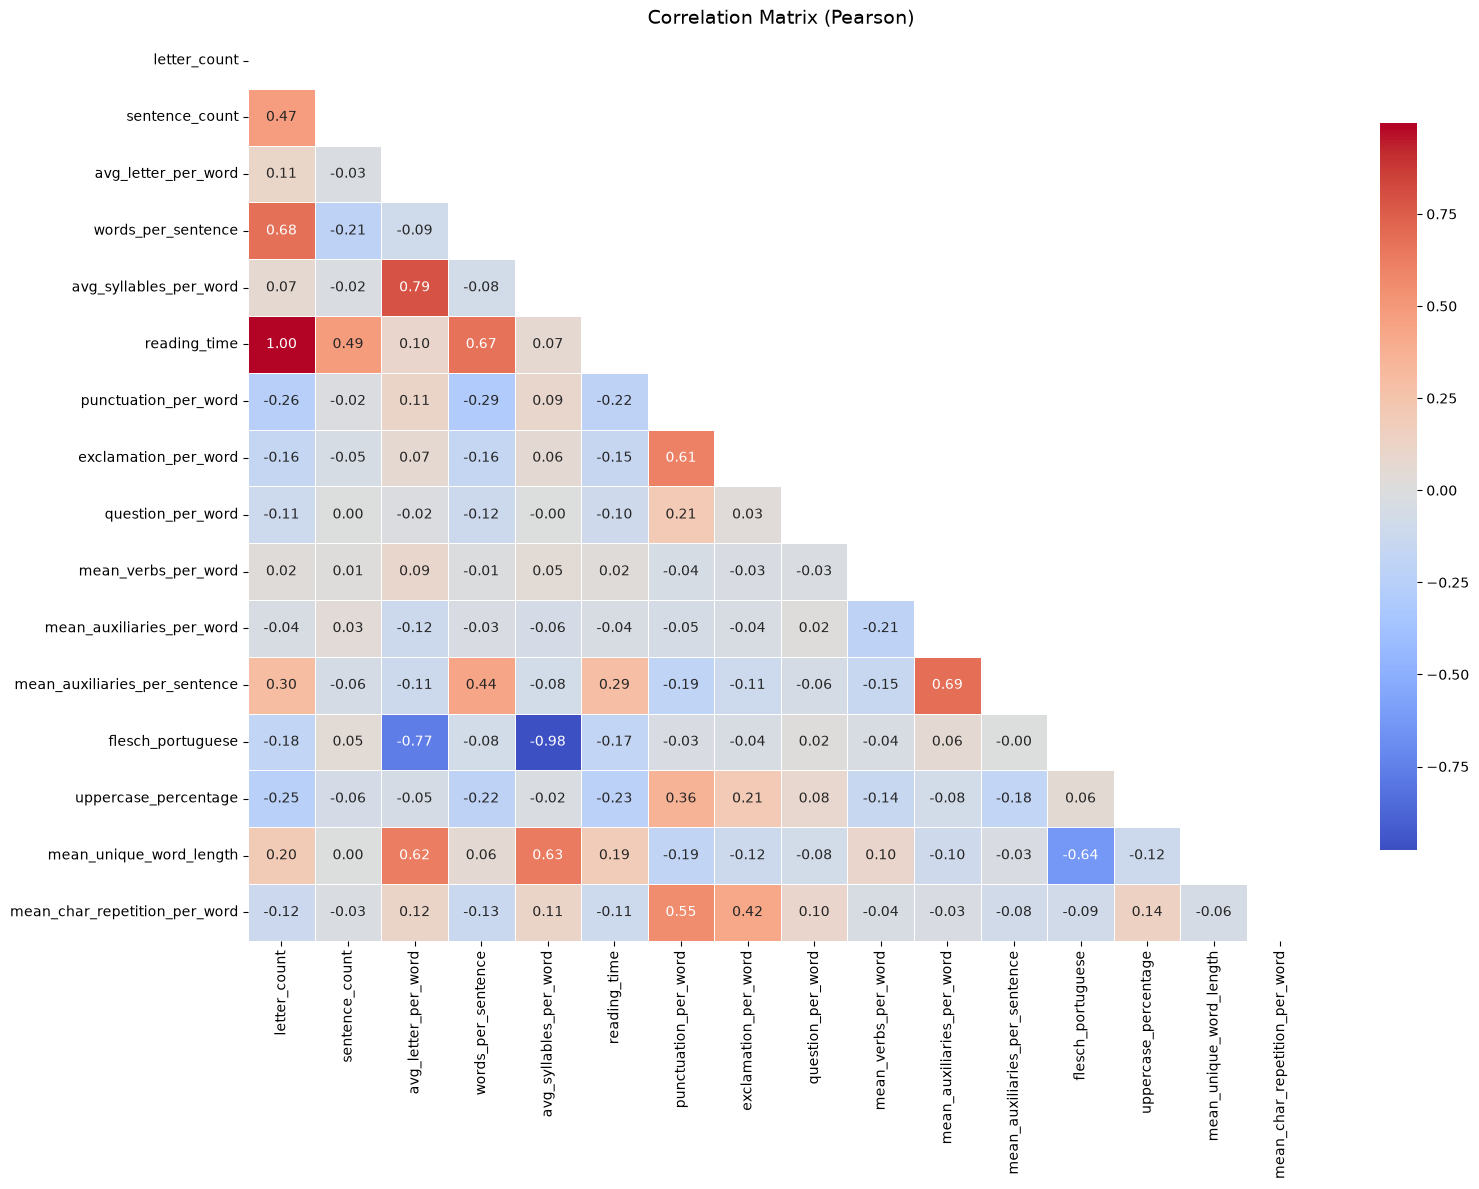

In [11]:
df['UNCLEAN_TEXT'] = (
    df['UNCLEAN_TEXT']
    .fillna("")        # remove NaN
    .astype(str)       # garante string
)

unclean_text_col = 'UNCLEAN_TEXT'

textstat_feats = get_textstat_features(df[unclean_text_col].tolist()) 

textstat_cols = [
    "letter_count",
    "sentence_count",
    "avg_letter_per_word",
    "words_per_sentence",
    "avg_syllables_per_word",
    "reading_time",
]

df_textstat = pd.DataFrame(textstat_feats, columns=textstat_cols) 
df = pd.concat([df.reset_index(drop=True), df_textstat.reset_index(drop=True)], axis=1)

punct_feats = mean_punctuation_per_word(df[unclean_text_col].tolist())

punct_cols = [
    "punctuation_per_word",
    "exclamation_per_word",
    "question_per_word"
]

df_punct = pd.DataFrame(punct_feats, columns=punct_cols)

df = pd.concat([df.reset_index(drop=True), df_punct], axis=1)

df["mean_verbs_per_word"] = mean_verbs_per_word(df[unclean_text_col])

df["mean_auxiliaries_per_word"] = mean_auxiliaries_per_word(df[unclean_text_col].tolist())
df["mean_auxiliaries_per_sentence"] = mean_auxiliaries_per_sentence(df[unclean_text_col].tolist())

df["flesch_portuguese"] = flesch_portuguese(df[unclean_text_col].tolist())

df["uppercase_percentage"] = uppercase_percentage(df[unclean_text_col].tolist())
df["mean_unique_word_length"] = mean_unique_word_length(df[unclean_text_col].tolist())
df["mean_char_repetition_per_word"] = mean_char_repetition_per_word(df[unclean_text_col].tolist())

emotion_cols = [
    'admiration', 'amusement', 'anger', 'annoyance',
    'approval', 'caring', 'confusion', 'curiosity', 'desire',
    'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
    'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]

num_cols = df.select_dtypes(include="number")
num_cols = [col for col in num_cols if col not in emotion_cols]
df_num = df[num_cols]
corr = df_num.corr(method="pearson")

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix (Pearson)", fontsize=14)
plt.tight_layout()
plt.show()

### Features adicionais (afetivas, lexicais e pragmáticas)

As features abaixo **complementam** (não substituem) as features de legibilidade/superfície já extraídas acima.
Todas são calculadas **linha a linha** (funções sem estado, sem estatística agregada do corpus) — ver a nota sobre
vazamento de dados no final desta seção.

| # | Grupo | Features geradas | O que mede | Por que faz sentido no GoEmotions | Referência que usa a ideia |
|---|-------|------------------|------------|-----------------------------------|----------------------------|
| 1 | **Sentimento contextual (BERT pronto)** | `sent_bert_neg`, `sent_bert_neu`, `sent_bert_pos`, `sent_bert_polarity`, `sent_bert_entropy` | Probabilidades (softmax) de um Transformer já ajustado para polaridade em PT-BR (`pysentimiento/bertweet-pt-sentiment` = BERTabaporu + TweetSentBR). `polarity = p_pos − p_neg`; `entropy` = incerteza do modelo | As 28 emoções do GoEmotions se agrupam em *positive / negative / ambiguous / neutral*; a polaridade é o eixo mais forte do rótulo. A entropia captura o grupo "ambíguo" (surprise, realization, curiosity) | Duppada, Jain & Hiray (2018) — 1º lugar no SemEval-2018 Task 1 usando **saídas de modelos de sentimento prontos como features**; Pérez et al. (2021); Brum & Nunes (2018) |
| 2 | **Sentimento léxico + regras (VADER-pt / LeIA)** | `leia_neg`, `leia_neu`, `leia_pos`, `leia_compound` | Léxico com regras de negação, intensificadores, CAPS, pontuação e emojis, adaptado ao português | Sinal barato, interpretável e complementar ao BERT; sensível a "!!!", CAPS e emojis, muito frequentes em comentários do Reddit | Hutto & Gilbert (2014) — VADER; Almeida (2018) — LeIA (fork PT) |
| 3 | **Léxico de polaridade (OpLexicon v3.0)** | `op_pos_ratio`, `op_neg_ratio`, `op_polarity_mean`, `op_polarity_neg_aware`, `op_coverage` | Proporção de palavras positivas/negativas anotadas por categoria morfológica; média de polaridade com heurística de negação em janela de 5 palavras | Segundo léxico, construído *nativamente* para o português (não traduzido) — reduz o viés de um único recurso | Souza et al. (2011); Souza & Vieira (2012) — inclusive a heurística de negação por janela |
| 3 | **Negação e modificadores de valência** | `negation_ratio`, `intensifier_ratio`, `downtoner_ratio`, `adversative_ratio` | Inversores ("não", "nunca", "nem"), intensificadores ("muito", "super"), atenuadores ("meio", "pouco") e adversativas ("mas", "porém") | Inversão/atenuação e contraste ("gostei, **mas**...") mudam o rótulo mesmo com o mesmo vocabulário — capturam *disappointment*, *disapproval*, *annoyance* | Taboada et al. (2011) — SO-CAL; Councill, McDonald & Velikovich (2010); Wilson, Wiebe & Hoffmann (2005) |

In [12]:
import math
import urllib.request
from collections import Counter

LEXICON_DIR = Path("../data/lexicons")
CACHE_DIR = Path("../data/cache")
LEXICON_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def norm_key(word: str) -> str:
    return _unidecode(str(word).strip().lower())

# OpLexicon v3.0
OPLEXICON_URL = "https://raw.githubusercontent.com/marlovss/OpLexicon/main/lexico_v3.0.txt"
OPLEXICON_PATH = LEXICON_DIR / "oplexicon_v3.0.txt"

if not OPLEXICON_PATH.exists():
    try:
        urllib.request.urlretrieve(OPLEXICON_URL, OPLEXICON_PATH)
        print(f"OpLexicon baixado em {OPLEXICON_PATH}")
    except Exception as e:
        print(f"[AVISO] Falha ao baixar o OpLexicon: {e}")

def load_oplexicon(path=OPLEXICON_PATH):
    words, emoticons = {}, {}
    if not Path(path).exists():
        print("[AVISO] OpLexicon ausente -> features op_* serão preenchidas com 0.")
        return words, emoticons

    with open(path, encoding="utf-8", errors="ignore") as f:
        for line in f:
            parts = line.strip().split(",")
            if len(parts) < 3:
                continue
            term, pos_tag, polarity = parts[0], parts[1], parts[2]
            try:
                polarity = int(polarity)
            except ValueError:
                continue
            if pos_tag == "emot":
                emoticons[term] = polarity
            else:
                words[norm_key(term)] = polarity
    return words, emoticons


OPLEXICON, OPLEXICON_EMOTICONS = load_oplexicon()
print(f"OpLexicon: {len(OPLEXICON)} palavras | {len(OPLEXICON_EMOTICONS)} emoticons")

# LeIA / VADER-pt
try:
    from LeIA import SentimentIntensityAnalyzer  # pip install leia-br

    LEIA_ANALYZER = SentimentIntensityAnalyzer()
    print("LeIA carregado.")
except Exception as e:
    LEIA_ANALYZER = None
    print(f"[AVISO] LeIA indisponível ({e}) -> features leia_* serão preenchidas com 0. "
          "Instale com: pip install leia-br")


OpLexicon: 31899 palavras | 51 emoticons
LeIA carregado.


In [13]:
NEGATIONS_PT = {
    "nao", "nem", "nunca", "jamais", "nada", "ninguem", "nenhum", "nenhuma",
    "nenhuns", "nenhumas", "tampouco", "sem",
}

# intensificadores / atenuadores
INTENSIFIERS_PT = {
    "muito", "muita", "muitos", "muitas", "bastante", "bem", "super", "hiper",
    "mega", "extremamente", "totalmente", "completamente", "absolutamente",
    "demais", "tao", "tanto", "realmente", "verdadeiramente", "profundamente",
    "incrivelmente", "excessivamente", "puta", "pra caralho", "demasiado",
}
DOWNTONERS_PT = {
    "pouco", "meio", "levemente", "ligeiramente", "quase", "apenas", "so",
    "talvez", "possivelmente", "raramente", "as vezes", "razoavelmente",
    "relativamente", "praticamente",
}

# conectivos adversativos / contraste (polarity shifters)
ADVERSATIVES_PT = {
    "mas", "porem", "todavia", "contudo", "entretanto", "embora", "apesar",
    "no entanto", "so que", "ainda assim",
}

def oplexicon_features(cache, negation_window=5):
    out = []
    for item in cache:
        forms, lemmas = item["forms"], item["lemmas"]
        n = len(forms)
        if n == 0:
            out.append([0.0] * 5)
            continue

        pols, pols_neg_aware = [], []
        for i, (form, lemma) in enumerate(zip(forms, lemmas)):
            pol = OPLEXICON.get(form, OPLEXICON.get(lemma))
            if pol is None:
                continue
            pols.append(pol)

            window = forms[max(0, i - negation_window):i]
            flipped = -pol if any(w in NEGATIONS_PT for w in window) else pol
            pols_neg_aware.append(flipped)

        if not pols:
            out.append([0.0, 0.0, 0.0, 0.0, 0.0])
            continue

        pols = np.array(pols, dtype=float)
        out.append([
            float((pols > 0).sum()) / n,          # op_pos_ratio
            float((pols < 0).sum()) / n,          # op_neg_ratio
            float(pols.mean()),                   # op_polarity_mean
            float(np.mean(pols_neg_aware)),       # op_polarity_neg_aware
            len(pols) / n,                        # op_coverage
        ])
    return np.array(out)

def lexical_marker_features(cache):
    out = []
    for item in cache:
        forms = item["forms"]
        n = len(forms)
        if n == 0:
            out.append([0.0] * 6)
            continue

        def ratio(vocab):
            return sum(1 for w in forms if w in vocab) / n

        counts = Counter(forms)
        ttr = len(counts) / n
        hapax = sum(1 for _, c in counts.items() if c == 1) / n

        out.append([
            ratio(NEGATIONS_PT),
            ratio(INTENSIFIERS_PT),
            ratio(DOWNTONERS_PT),
            ratio(ADVERSATIVES_PT),
            ttr,
            hapax,
        ])

    assert all(len(x) == 6 for x in out)
    
    return np.asarray(out, dtype=np.float32)

# LeIA / VADER-pt
def leia_features(texts):
    if LEIA_ANALYZER is None:
        return np.zeros((len(texts), 4))
    out = []
    for txt in texts:
        s = LEIA_ANALYZER.polarity_scores(str(txt))
        out.append([s["neg"], s["neu"], s["pos"], s["compound"]])
    return np.array(out)

def build_spacy_cache(texts, batch_size=256):
    cache = []
    for doc in nlp.pipe(list(texts), batch_size=batch_size, disable=["ner"]):
        toks = [t for t in doc if t.is_alpha]
        cache.append({
            "lemmas": [norm_key(t.lemma_) for t in toks],
            "forms": [norm_key(t.text) for t in toks],
            "pos": [t.pos_ for t in toks],
        })
    return cache

In [14]:
# Sentimento contextual: BERT/RoBERTa já ajustado para polaridade em PT

import torch
from scipy.special import softmax
from transformers import AutoTokenizer, AutoModelForSequenceClassification

SENT_MODEL_NAME = "pysentimiento/bertweet-pt-sentiment"
SENT_CACHE_PATH = CACHE_DIR / f"sent_probs_{SENT_MODEL_NAME.replace('/', '_')}.parquet"

def _preprocess_social(text: str) -> str:
    tokens = []
    for t in str(text).split(" "):
        if t.startswith("@") and len(t) > 1:
            t = "@user"
        elif t.startswith("http"):
            t = "http"
        tokens.append(t)
    return " ".join(tokens)


@torch.no_grad()
def transformer_sentiment_probs(
    texts,
    model_name=SENT_MODEL_NAME,
    batch_size=64,
    max_length=128,
    device=None,
    use_cache=True,
):
    if use_cache and SENT_CACHE_PATH.exists():
        cached = pd.read_parquet(SENT_CACHE_PATH)
        if len(cached) == len(texts):
            print(f"Probabilidades de sentimento carregadas do cache: {SENT_CACHE_PATH}")
            return cached[["sent_bert_neg", "sent_bert_neu", "sent_bert_pos"]].values

    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Rodando {model_name} em {device} ...")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name)
    model.to(device).eval()

    # mapeia os rótulos do modelo (POS/NEG/NEU, Positive/Negative/Neutral, ...) -> [neg, neu, pos]
    id2label = {i: str(l).lower() for i, l in model.config.id2label.items()}
    order = []
    for prefix in ("neg", "neu", "pos"):
        idx = [i for i, l in id2label.items() if l.startswith(prefix)]
        if not idx:
            raise ValueError(f"Não achei o rótulo '{prefix}' em {id2label}")
        order.append(idx[0])

    prepared = [_preprocess_social(t) for t in texts]
    probs = np.zeros((len(prepared), 3), dtype=np.float32)

    for start in range(0, len(prepared), batch_size):
        batch = prepared[start:start + batch_size]
        enc = tokenizer(
            batch, padding=True, truncation=True,
            max_length=max_length, return_tensors="pt",
        ).to(device)
        logits = model(**enc).logits.detach().cpu().numpy()
        p = softmax(logits, axis=1)
        probs[start:start + len(batch)] = p[:, order]

        if (start // batch_size) % 50 == 0:
            print(f"  {start}/{len(prepared)}", end="\r")

    if use_cache:
        pd.DataFrame(
            probs, columns=["sent_bert_neg", "sent_bert_neu", "sent_bert_pos"]
        ).to_parquet(SENT_CACHE_PATH, index=False)
        print(f"\nCache salvo em {SENT_CACHE_PATH}")

    return probs

def entropy_from_probs(p, eps=1e-9):
    p = np.clip(p, eps, 1.0)
    return -(p * np.log(p)).sum(axis=1) / math.log(p.shape[1])

c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
df = df.reset_index(drop=True)
texts = df[unclean_text_col].astype(str).tolist()

# --- passe único do spaCy, reaproveitado por vários grupos de features ---
spacy_cache = build_spacy_cache(texts)
print("spaCy cache pronto.")

new_feature_groups = {}

# 1) Sentimento contextual (BERT pronto)  -----------------------------
sent_probs = transformer_sentiment_probs(texts)
sent_block = np.column_stack([
    sent_probs,
    sent_probs[:, 2] - sent_probs[:, 0],      # polaridade = p_pos - p_neg
    entropy_from_probs(sent_probs),           # ambiguidade
])
new_feature_groups["bert"] = (
    ["sent_bert_neg", "sent_bert_neu", "sent_bert_pos",
     "sent_bert_polarity", "sent_bert_entropy"],
    sent_block,
)

# 2) LeIA / VADER-pt  -------------------------------------------------
new_feature_groups["leia"] = (
    ["leia_neg", "leia_neu", "leia_pos", "leia_compound"],
    leia_features(texts),
)

# 3) OpLexicon  -------------------------------------------------------
new_feature_groups["oplexicon"] = (
    ["op_pos_ratio", "op_neg_ratio", "op_polarity_mean",
     "op_polarity_neg_aware", "op_coverage"],
    oplexicon_features(spacy_cache),
)

# 4) Pronomes, negação, modificadores, diversidade, cue words --
new_feature_groups["markers"] = (
    ["negation_ratio", "intensifier_ratio", "downtoner_ratio",
     "adversative_ratio", "ttr", "hapax"],
    lexical_marker_features(spacy_cache),
)

new_feature_cols = []
for group, (cols, values) in new_feature_groups.items():
    block = pd.DataFrame(values, columns=cols)
    df = pd.concat([df.reset_index(drop=True), block], axis=1)
    new_feature_cols.extend(cols)

print(f"\n{len(new_feature_cols)} novas features criadas:")
print(new_feature_cols)

# sanity check: nada de NaN/inf e variância > 0
new_block = df[new_feature_cols]
print("\nNaN por feature (esperado: 0):", int(new_block.isna().sum().sum()))
print("Colunas constantes (candidatas a descarte):",
      [c for c in new_feature_cols if new_block[c].std() == 0])

df[new_feature_cols].describe().T


spaCy cache pronto.
Probabilidades de sentimento carregadas do cache: ..\data\cache\sent_probs_pysentimiento_bertweet-pt-sentiment.parquet

20 novas features criadas:
['sent_bert_neg', 'sent_bert_neu', 'sent_bert_pos', 'sent_bert_polarity', 'sent_bert_entropy', 'leia_neg', 'leia_neu', 'leia_pos', 'leia_compound', 'op_pos_ratio', 'op_neg_ratio', 'op_polarity_mean', 'op_polarity_neg_aware', 'op_coverage', 'negation_ratio', 'intensifier_ratio', 'downtoner_ratio', 'adversative_ratio', 'ttr', 'hapax']

NaN por feature (esperado: 0): 0
Colunas constantes (candidatas a descarte): []


,count,mean,std,min,25%,50%,75%,max
sent_bert_neg,54234.0,0.262662,0.333437,0.001273,0.024920,0.079888,0.419862,0.993157
sent_bert_neu,54234.0,0.501439,0.350546,0.003257,0.115037,0.566346,0.847218,0.980379
sent_bert_pos,54234.0,0.235899,0.336921,0.001998,0.017565,0.045099,0.325654,0.993828
sent_bert_polarity,54234.0,-0.026763,0.571409,-0.990305,-0.374860,-0.023810,0.260146,0.992108
sent_bert_entropy,54234.0,0.443095,0.230053,0.037510,0.250136,0.441512,0.642909,0.999742
leia_neg,54234.0,0.143877,0.166863,0.000000,0.000000,0.106000,0.239000,1.000000
leia_neu,54234.0,0.683899,0.218193,0.000000,0.544000,0.687000,0.838000,1.000000
leia_pos,54234.0,0.172221,0.197520,0.000000,0.000000,0.128000,0.278000,1.000000
leia_compound,54234.0,0.030578,0.449965,-0.990800,-0.296000,0.000000,0.401900,0.973500
op_pos_ratio,54234.0,0.148882,0.124343,0.000000,0.066667,0.133333,0.208333,1.000000


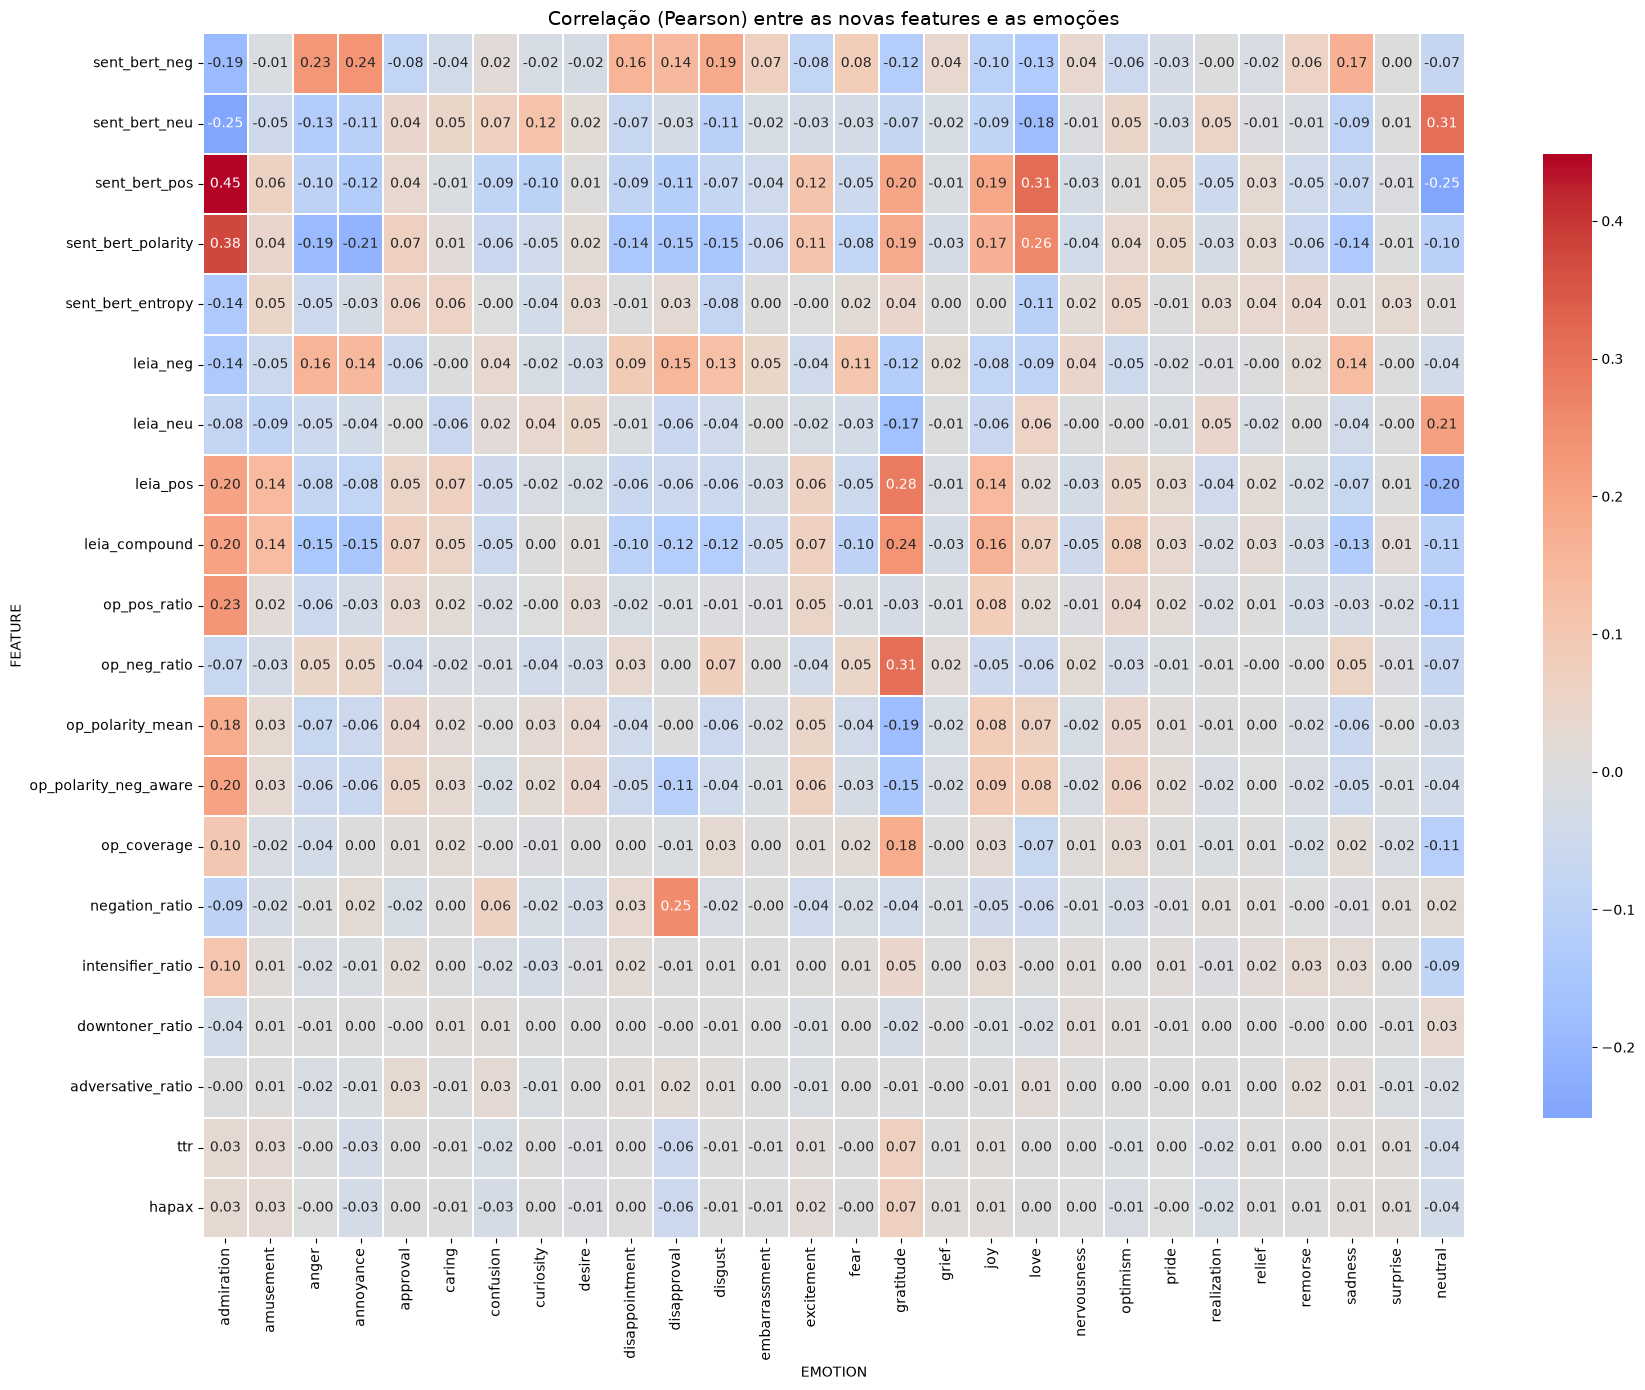

Pares (feature, emoção) mais correlacionados:
sent_bert_pos       admiration     0.448717
sent_bert_polarity  admiration     0.375087
sent_bert_pos       love           0.314665
op_neg_ratio        gratitude      0.307176
sent_bert_neu       neutral        0.306873
leia_pos            gratitude      0.284607
sent_bert_polarity  love           0.260483
negation_ratio      disapproval    0.253932
sent_bert_neu       admiration     0.251140
sent_bert_pos       neutral        0.248416
sent_bert_neg       annoyance      0.236959
leia_compound       gratitude      0.236416
op_pos_ratio        admiration     0.233320
sent_bert_neg       anger          0.228946
sent_bert_polarity  annoyance      0.210966
dtype: float64


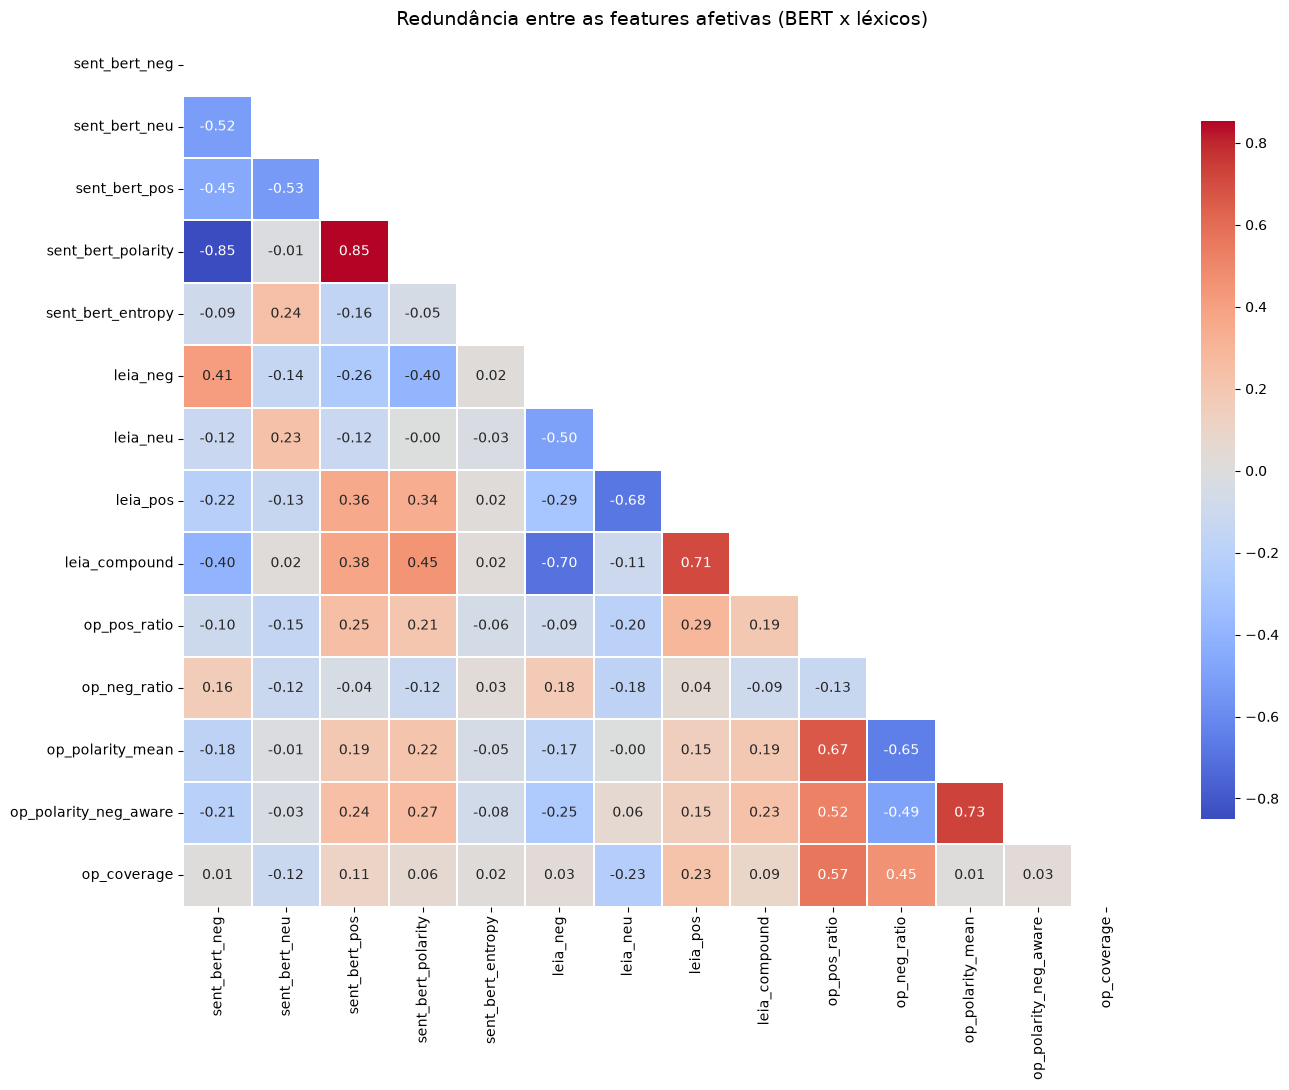

In [20]:
corr_new = pd.DataFrame(
    {emo: df[new_feature_cols].corrwith(df[emo]) for emo in emotion_cols}
)

plt.figure(figsize=(18, 14))
sns.heatmap(
    corr_new,
    cmap="coolwarm",
    center=0,
    annot=True, 
    fmt=".2f",
    linewidths=0.3,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlação (Pearson) entre as novas features e as emoções", fontsize=14)
plt.xlabel("EMOTION")
plt.ylabel("FEATURE")
plt.tight_layout()
plt.show()

# top 15 pares feature-emoção por correlação absoluta
top_pairs = (
    corr_new.stack()
    .abs()
    .sort_values(ascending=False)
    .head(15)
)
print("Pares (feature, emoção) mais correlacionados:")
print(top_pairs)

# redundância entre as novas features de sentimento
sent_like = [c for c in new_feature_cols
             if c.startswith(("sent_bert", "leia", "op_", "nrc_", "vad_"))]
plt.figure(figsize=(14, 11))
sns.heatmap(
    df[sent_like].corr(),
    mask=np.triu(np.ones((len(sent_like), len(sent_like)), dtype=bool)),
    cmap="coolwarm", center=0, annot=True, fmt=".2f", linewidths=0.3,
    cbar_kws={"shrink": 0.8},
)
plt.title("Redundância entre as features afetivas (BERT x léxicos)", fontsize=14)
plt.tight_layout()
plt.show()

## Divisão em Folds

In [17]:
y = df[emotion_cols]

output_dir = Path("../data/treated")
output_dir.mkdir(parents=True, exist_ok=True)

mskf = MultilabelStratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# O split precisa de X, mas ele não é utilizado pela estratificação
X_dummy = np.zeros((len(df), 1))

for fold, (_, fold_idx) in enumerate(mskf.split(X_dummy, y), start=1):
    fold_dir = output_dir / f"fold_{fold}"
    fold_dir.mkdir(parents=True, exist_ok=True)

    fold_df = df.iloc[fold_idx].reset_index(drop=True)

    fold_df.to_parquet(fold_dir / "data.parquet", index=False)
    np.save(fold_dir / "idx.npy", fold_idx)

print("5 folds criados com sucesso.")

5 folds criados com sucesso.
